In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import matplotlib.pyplot as plt

# ============================================================
# 1. 파일 불러오기
# ============================================================

# 원유민감 물가지수 파일
ppi = pd.read_excel(
    "원유민감_물가지수_결과.xlsx",
    sheet_name="PPI_2000이후"
)

cpi = pd.read_excel(
    "원유민감_물가지수_결과.xlsx",
    sheet_name="CPI_2000이후"
)

# 국제유가 파일
oil = pd.read_excel("국제 유가.xlsx")


# ============================================================
# 2. 날짜 형식 통일
# ============================================================

ppi["날짜"] = pd.to_datetime(ppi["날짜"])
cpi["날짜"] = pd.to_datetime(cpi["날짜"])
oil["년도"] = pd.to_datetime(oil["년도"]) # Changed '날짜' to '년도'


# ============================================================
# 3. 필요한 컬럼만 선택
# ============================================================

ppi = ppi[["날짜", "원유민감_PPI"]]
cpi = cpi[["날짜", "원유민감_CPI"]]
oil = oil[["년도", "두바이유 가격"]] # Changed '날짜' to '년도' and '국제유가' to '두바이유 가격'
oil.rename(columns={'년도': '날짜', '두바이유 가격': '국제유가'}, inplace=True) # Rename for consistency


# ============================================================
# 4. 데이터 병합
# ============================================================
# 날짜 기준으로 병합

df = pd.merge(ppi, cpi, on="날짜", how="inner")
df = pd.merge(df, oil, on="날짜", how="inner")

# ============================================================
# 5. 로그 및 차분 변수 생성 (단위근 해결의 핵심)
# ============================================================
# 수준 변수 로그화
df["ln_oil"] = np.log(df["국제유가"])
df["ln_ppi"] = np.log(df["원유민감_PPI"])
df["ln_cpi"] = np.log(df["원유민감_CPI"])

# 1차 차분(수익률/변화율 개념) 생성: 단위근 문제 해결을 위함
df["d_ln_oil"] = df["ln_oil"].diff()
df["d_ln_ppi"] = df["ln_ppi"].diff()
df["d_ln_cpi"] = df["ln_cpi"].diff()

# 차분 변수 기준 시차(Lag) 생성
df["d_oil_lag1"] = df["d_ln_oil"].shift(1)
df["d_oil_lag3"] = df["d_ln_oil"].shift(3)
df["d_oil_lag6"] = df["d_ln_oil"].shift(6)

df = df.dropna().reset_index(drop=True)

# ============================================================
# 6. 단위근 검정 (ADF Test) / 데이터가 안정적인지 확
# ============================================================
def check_adfuller(series, name):
    result = adfuller(series)
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("결과: Stationary (안정적, 사용 가능)")
    else:
        print("결과: Non-Stationary (불안정, 차분 필요)")
    print("")

check_adfuller(df["d_ln_oil"], "유가 차분")
check_adfuller(df["d_ln_ppi"], "PPI 차분")

# ============================================================
# 7. 다중공선성 검정 (VIF)
# ============================================================
X_vars = ["d_ln_oil", "d_oil_lag1", "d_oil_lag3", "d_oil_lag6"]
X_vif = df[X_vars]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("--- 다중공선성(VIF) 결과 ---")
print(vif_data)
print("※ VIF > 10이면 다중공선성 위험이 높음\n")

# ============================================================
# 8. 수정된 회귀분석 (차분 변수 사용)
# ============================================================
# PPI 분석
X_final = sm.add_constant(df[X_vars])
y_ppi = df["d_ln_ppi"]
model_ppi_fixed = sm.OLS(y_ppi, X_final).fit()

# CPI 분석
y_cpi = df["d_ln_cpi"]
model_cpi_fixed = sm.OLS(y_cpi, X_final).fit()

# ============================================================
# 9. 자기상관성 검정 (Durbin-Watson & Breusch-Godfrey)
# ============================================================
def check_autocorr(model):
    # Durbin-Watson: 2에 가까울수록 자기상관 없음
    dw = sm.stats.stattools.durbin_watson(model.resid)
    # Breusch-Godfrey: p-value > 0.05면 자기상관 없음
    bg_test = acorr_breusch_godfrey(model, nlags=4)

    print(f"Durbin-Watson: {dw:.4f}")
    print(f"Breusch-Godfrey p-value: {bg_test[1]:.4f}")
    if bg_test[1] < 0.05:
        print("결과: 자기상관 존재 (HAC standard errors 사용 권장)")
    else:
        print("결과: 자기상관 없음")

print("--- PPI 모델 자기상관 검정 ---")
check_autocorr(model_ppi_fixed)

# ============================================================
# 10. 자기상관 해결 (HAC Standard Errors 적용)
# ============================================================
# 자기상관이 발견될 경우, 계수값은 유지하되 표준오차를 수정하여 p-value의 신뢰도를 높임
model_ppi_hac = model_ppi_fixed.get_robustcov_results(cov_type='HAC', maxlags=4)
model_cpi_hac = model_cpi_fixed.get_robustcov_results(cov_type='HAC', maxlags=4)

print("\n" + "="*60)
print("최종 수정된 PPI 회귀분석 결과 (차분 및 HAC 적용)")
print("="*60)
print(model_ppi_hac.summary2())
print("\n" + "="*60)
print("최종 수정된 CPI 회귀분석 결과 (차분 및 HAC 적용)")
print("="*60)
print(model_cpi_hac.summary2())

--- ADF Test: 유가 차분 ---
ADF Statistic: -9.3255
p-value: 0.0000
결과: Stationary (안정적, 사용 가능)

--- ADF Test: PPI 차분 ---
ADF Statistic: -11.2656
p-value: 0.0000
결과: Stationary (안정적, 사용 가능)

--- 다중공선성(VIF) 결과 ---
     Variable       VIF
0       const  1.007355
1    d_ln_oil  1.136307
2  d_oil_lag1  1.120907
3  d_oil_lag3  1.022631
4  d_oil_lag6  1.012424
※ VIF > 10이면 다중공선성 위험이 높음

--- PPI 모델 자기상관 검정 ---
Durbin-Watson: 1.5539
Breusch-Godfrey p-value: 0.0000
결과: 자기상관 존재 (HAC standard errors 사용 권장)

최종 수정된 PPI 회귀분석 결과 (차분 및 HAC 적용)
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.731     
Dependent Variable: d_ln_ppi         AIC:                -1528.2896
Date:               2026-05-19 15:48 BIC:                -1509.6717
No. Observations:   306              Log-Likelihood:     769.14    
Df Model:           4                F-statistic:        121.7     
Df Residuals:       301              Prob (F-statistic): 1.25e-61  
R-squared:  

In [ ]:
#기여율 회귀 돌린거
# ============================================================
# 11. 전가효과 기여율 분석
# ============================================================

print("\n" + "="*60)
print("PPI 전가효과 기여율")
print("="*60)

# ------------------------------------------------------------
# PPI 계수 추출
# ------------------------------------------------------------

ppi_coef = pd.Series({
    "현재 유가": model_ppi_hac.params[1],
    "1개월 시차": model_ppi_hac.params[2],
    "3개월 시차": model_ppi_hac.params[3],
    "6개월 시차": model_ppi_hac.params[4]
})

# 절댓값 기준 총효과
ppi_total = ppi_coef.abs().sum()

# 기여율 계산
ppi_contrib = (ppi_coef.abs() / ppi_total) * 100

ppi_result = pd.DataFrame({
    "계수": ppi_coef,
    "기여율(%)": ppi_contrib
})

print(ppi_result)

print("\n")
print(f"PPI 총 전가효과: {ppi_total:.4f}")


# ============================================================
# CPI 기여율 분석
# ============================================================

print("\n" + "="*60)
print("CPI 전가효과 기여율")
print("="*60)

# ------------------------------------------------------------
# CPI 계수 추출
# ------------------------------------------------------------

cpi_coef = pd.Series({
    "현재 유가": model_cpi_hac.params[1],
    "1개월 시차": model_cpi_hac.params[2],
    "3개월 시차": model_cpi_hac.params[3],
    "6개월 시차": model_cpi_hac.params[4]
})

# 절댓값 기준 총효과
cpi_total = cpi_coef.abs().sum()

# 기여율 계산
cpi_contrib = (cpi_coef.abs() / cpi_total) * 100

cpi_result = pd.DataFrame({
    "계수": cpi_coef,
    "기여율(%)": cpi_contrib
})

print(cpi_result)

print("\n")
print(f"CPI 총 전가효과: {cpi_total:.4f}")


PPI 전가효과 기여율
              계수     기여율(%)
현재 유가   0.227260  49.691820
1개월 시차  0.207404  45.350136
3개월 시차  0.001945   0.425314
6개월 시차  0.020730   4.532729


PPI 총 전가효과: 0.4573

CPI 전가효과 기여율
              계수     기여율(%)
현재 유가   0.081808  27.311248
1개월 시차  0.195801  65.367620
3개월 시차  0.015806   5.276950
6개월 시차 -0.006123   2.044183


CPI 총 전가효과: 0.2995


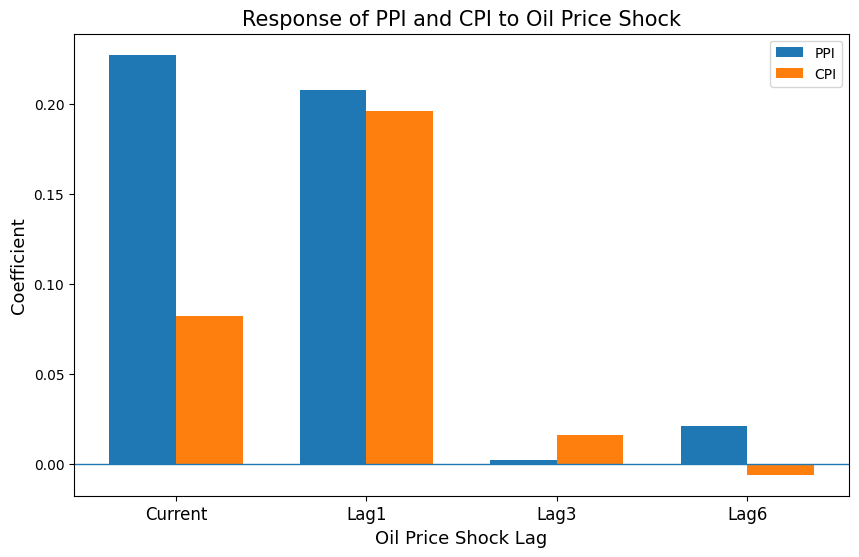

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. 계수값 입력
# ============================================================

labels = ["Current", "Lag1", "Lag3", "Lag6"]

ppi_coef = [
    model_ppi_hac.params[1],   # d_ln_oil
    model_ppi_hac.params[2],   # lag1
    model_ppi_hac.params[3],   # lag3
    model_ppi_hac.params[4]    # lag6
]

cpi_coef = [
    model_cpi_hac.params[1],
    model_cpi_hac.params[2],
    model_cpi_hac.params[3],
    model_cpi_hac.params[4]
]

# ============================================================
# 2. 그래프 위치 설정
# ============================================================

x = np.arange(len(labels))
width = 0.35

# ============================================================
# 3. 그래프 생성
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(x - width/2, ppi_coef, width, label="PPI")
plt.bar(x + width/2, cpi_coef, width, label="CPI")

# ============================================================
# 4. 그래프 꾸미기
# ============================================================

plt.axhline(0, linewidth=1)

plt.xticks(x, labels, fontsize=12)

plt.ylabel("Coefficient", fontsize=13)
plt.xlabel("Oil Price Shock Lag", fontsize=13)

plt.title("Response of PPI and CPI to Oil Price Shock", fontsize=15)

plt.legend()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# ============================================================
# 1. 파일 불러오기
# ============================================================

# 원유민감 물가지수
ppi = pd.read_excel(
    "원유민감_물가지수_결과.xlsx",
    sheet_name="PPI_2000이후"
)

cpi = pd.read_excel(
    "원유민감_물가지수_결과.xlsx",
    sheet_name="CPI_2000이후"
)

# 국제유가
oil = pd.read_excel("국제 유가.xlsx")

# 환율 데이터
exchange = pd.read_excel("원달러환율_월별평균.xlsx")


# ============================================================
# 2. 날짜 형식 통일
# ============================================================

ppi["날짜"] = pd.to_datetime(ppi["날짜"])
cpi["날짜"] = pd.to_datetime(cpi["날짜"])

oil["년도"] = pd.to_datetime(oil["년도"])
exchange["날짜"] = pd.to_datetime(exchange["날짜"])


# ============================================================
# 3. 필요한 컬럼만 선택
# ============================================================

ppi = ppi[["날짜", "원유민감_PPI"]]

cpi = cpi[["날짜", "원유민감_CPI"]]

oil = oil[["년도", "두바이유 가격"]]
oil.rename(columns={
    "년도": "날짜",
    "두바이유 가격": "국제유가"
}, inplace=True)

exchange = exchange[["날짜", "원달러환율_월평균"]]
exchange.rename(columns={
    "원달러환율_월평균": "환율"
}, inplace=True)


# ============================================================
# 4. 데이터 병합
# ============================================================

df = pd.merge(ppi, cpi, on="날짜", how="inner")
df = pd.merge(df, oil, on="날짜", how="inner")
df = pd.merge(df, exchange, on="날짜", how="inner")


# ============================================================
# 5. 로그 변환
# ============================================================

df["ln_oil"] = np.log(df["국제유가"])
df["ln_ppi"] = np.log(df["원유민감_PPI"])
df["ln_cpi"] = np.log(df["원유민감_CPI"])
df["ln_exchange"] = np.log(df["환율"])


# ============================================================
# 6. 차분 변수 생성
# ============================================================

df["d_ln_oil"] = df["ln_oil"].diff()

df["d_ln_ppi"] = df["ln_ppi"].diff()

df["d_ln_cpi"] = df["ln_cpi"].diff()

df["d_ln_exchange"] = df["ln_exchange"].diff()


# ============================================================
# 7. 유가 시차 변수 생성
# ============================================================

df["d_oil_lag1"] = df["d_ln_oil"].shift(1)

df["d_oil_lag3"] = df["d_ln_oil"].shift(3)

df["d_oil_lag6"] = df["d_ln_oil"].shift(6)


# ============================================================
# 8. 결측 제거
# ============================================================

df = df.dropna().reset_index(drop=True)


# ============================================================
# 9. ADF 검정
# ============================================================

def check_adfuller(series, name):

    result = adfuller(series)

    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("결과: Stationary")
    else:
        print("결과: Non-Stationary")


check_adfuller(df["d_ln_oil"], "유가 차분")
check_adfuller(df["d_ln_exchange"], "환율 차분")


# ============================================================
# 10. 독립변수 설정
# ============================================================

X_vars = [
    "d_ln_oil",
    "d_oil_lag1",
    "d_oil_lag3",
    "d_oil_lag6",
    "d_ln_exchange"
]


# ============================================================
# 11. VIF 확인
# ============================================================

X_vif = sm.add_constant(df[X_vars])

vif_data = pd.DataFrame()

vif_data["Variable"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\n==============================")
print("VIF 결과")
print("==============================")

print(vif_data)


# ============================================================
# 12. 회귀분석
# ============================================================

X_final = sm.add_constant(df[X_vars])

# -----------------------------
# PPI
# -----------------------------

y_ppi = df["d_ln_ppi"]

model_ppi = sm.OLS(y_ppi, X_final).fit()

model_ppi_hac = model_ppi.get_robustcov_results(
    cov_type='HAC',
    maxlags=4
)

# -----------------------------
# CPI
# -----------------------------

y_cpi = df["d_ln_cpi"]

model_cpi = sm.OLS(y_cpi, X_final).fit()

model_cpi_hac = model_cpi.get_robustcov_results(
    cov_type='HAC',
    maxlags=4
)


# ============================================================
# 13. 결과 출력
# ============================================================

print("\n" + "="*70)
print("PPI 회귀분석 결과 (환율 통제 포함)")
print("="*70)

print(model_ppi_hac.summary2())


print("\n" + "="*70)
print("CPI 회귀분석 결과 (환율 통제 포함)")
print("="*70)

print(model_cpi_hac.summary2())


# ============================================================
# 14. 자기상관 확인
# ============================================================

def check_autocorr(model):

    dw = sm.stats.stattools.durbin_watson(model.resid)

    bg_test = acorr_breusch_godfrey(model, nlags=4)

    print(f"\nDurbin-Watson: {dw:.4f}")
    print(f"Breusch-Godfrey p-value: {bg_test[1]:.4f}")

    if bg_test[1] < 0.05:
        print("자기상관 존재")
    else:
        print("자기상관 없음")


print("\n==============================")
print("PPI 자기상관 검정")
print("==============================")

check_autocorr(model_ppi)


print("\n==============================")
print("CPI 자기상관 검정")
print("==============================")

check_autocorr(model_cpi)


--- ADF Test: 유가 차분 ---
ADF Statistic: -9.3255
p-value: 0.0000
결과: Stationary

--- ADF Test: 환율 차분 ---
ADF Statistic: -11.9725
p-value: 0.0000
결과: Stationary

VIF 결과
        Variable       VIF
0          const  1.010206
1       d_ln_oil  1.201671
2     d_oil_lag1  1.121697
3     d_oil_lag3  1.022858
4     d_oil_lag6  1.037862
5  d_ln_exchange  1.101055

PPI 회귀분석 결과 (환율 통제 포함)
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.777     
Dependent Variable: d_ln_ppi         AIC:                -1585.4499
Date:               2026-05-19 15:48 BIC:                -1563.1084
No. Observations:   306              Log-Likelihood:     798.72    
Df Model:           5                F-statistic:        162.5     
Df Residuals:       300              Prob (F-statistic): 3.75e-83  
R-squared:          0.781            Scale:              0.00032279
--------------------------------------------------------------------
                  Coef.  

In [ ]:
# ============================================================
# 1. 파일 불러오기
# ============================================================

ppi = pd.read_excel("원유민감_물가지수_결과.xlsx", sheet_name="PPI_2000이후")
cpi = pd.read_excel("원유민감_물가지수_결과.xlsx", sheet_name="CPI_2000이후")
oil = pd.read_excel("국제 유가.xlsx")
exchange = pd.read_excel("원달러환율_월별평균.xlsx")

# 원유비축량 데이터 추가
stock = pd.read_excel("원유비축량_월별변환_수정본.xlsx")


# ============================================================
# 2. 날짜 형식 통일
# ============================================================

ppi["날짜"] = pd.to_datetime(ppi["날짜"])
cpi["날짜"] = pd.to_datetime(cpi["날짜"])
oil["년도"] = pd.to_datetime(oil["년도"])
exchange["날짜"] = pd.to_datetime(exchange["날짜"])

# 2004.01 형식 → 날짜 형식으로 변환
stock["날짜"] = pd.to_datetime(stock["날짜"].astype(str), format="%Y.%m")


# ============================================================
# 3. 필요한 컬럼만 선택
# ============================================================

ppi = ppi[["날짜", "원유민감_PPI"]]
cpi = cpi[["날짜", "원유민감_CPI"]]

oil = oil[["년도", "두바이유 가격"]]
oil.rename(columns={"년도": "날짜", "두바이유 가격": "국제유가"}, inplace=True)

exchange = exchange[["날짜", "원달러환율_월평균"]]
exchange.rename(columns={"원달러환율_월평균": "환율"}, inplace=True)

stock = stock[["날짜", "비축유 비축량(백만배럴)"]]
stock.rename(columns={"비축유 비축량(백만배럴)": "원유비축량"}, inplace=True)


# ============================================================
# 4. 데이터 병합
# ============================================================

df = pd.merge(ppi, cpi, on="날짜", how="inner")
df = pd.merge(df, oil, on="날짜", how="inner")
df = pd.merge(df, exchange, on="날짜", how="inner")
df = pd.merge(df, stock, on="날짜", how="inner")

# 비축량 데이터가 2004년부터 있으므로 실제 회귀기간 확인
print(df["날짜"].min(), df["날짜"].max())


# ============================================================
# 5. 로그 변환
# ============================================================

df["ln_oil"] = np.log(df["국제유가"])
df["ln_ppi"] = np.log(df["원유민감_PPI"])
df["ln_cpi"] = np.log(df["원유민감_CPI"])
df["ln_exchange"] = np.log(df["환율"])
df["ln_stock"] = np.log(df["원유비축량"])


# ============================================================
# 6. 차분 변수 생성
# ============================================================

df["d_ln_oil"] = df["ln_oil"].diff()
df["d_ln_ppi"] = df["ln_ppi"].diff()
df["d_ln_cpi"] = df["ln_cpi"].diff()
df["d_ln_exchange"] = df["ln_exchange"].diff()

# 비축량 변화율
df["d_ln_stock"] = df["ln_stock"].diff()


# ============================================================
# 7. 유가 시차 변수 생성
# ============================================================

df["d_oil_lag1"] = df["d_ln_oil"].shift(1)
df["d_oil_lag3"] = df["d_ln_oil"].shift(3)
df["d_oil_lag6"] = df["d_ln_oil"].shift(6)


# ============================================================
# 8. 결측 제거
# ============================================================

df = df.dropna().reset_index(drop=True)


# ============================================================
# 9. ADF 검정
# ============================================================

check_adfuller(df["d_ln_oil"], "유가 차분")
check_adfuller(df["d_ln_exchange"], "환율 차분")
check_adfuller(df["d_ln_stock"], "원유비축량 차분")


# ============================================================
# 10. 독립변수 설정
# ============================================================

X_vars = [
    "d_ln_oil",
    "d_oil_lag1",
    "d_oil_lag3",
    "d_oil_lag6",
    "d_ln_exchange",
    "d_ln_stock"
]


# ============================================================
# 11. VIF 확인
# ============================================================

X_vif = sm.add_constant(df[X_vars])

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\n==============================")
print("VIF 결과")
print("==============================")
print(vif_data)


# ============================================================
# 12. 회귀분석
# ============================================================

X_final = sm.add_constant(df[X_vars])

# PPI
y_ppi = df["d_ln_ppi"]
model_ppi = sm.OLS(y_ppi, X_final).fit()
model_ppi_hac = model_ppi.get_robustcov_results(cov_type="HAC", maxlags=4)

# CPI
y_cpi = df["d_ln_cpi"]
model_cpi = sm.OLS(y_cpi, X_final).fit()
model_cpi_hac = model_cpi.get_robustcov_results(cov_type="HAC", maxlags=4)


# ============================================================
# 13. 결과 출력
# ============================================================

print("\n" + "="*70)
print("PPI 회귀분석 결과 (환율 + 원유비축량 통제 포함)")
print("="*70)
print(model_ppi_hac.summary2())

print("\n" + "="*70)
print("CPI 회귀분석 결과 (환율 + 원유비축량 통제 포함)")
print("="*70)
print(model_cpi_hac.summary2())


# ============================================================
# 14. 자기상관 확인
# ============================================================

print("\n==============================")
print("PPI 자기상관 검정")
print("==============================")
check_autocorr(model_ppi)

print("\n==============================")
print("CPI 자기상관 검정")
print("==============================")
check_autocorr(model_cpi)

2004-01-01 00:00:00 2025-12-01 00:00:00

--- ADF Test: 유가 차분 ---
ADF Statistic: -10.0072
p-value: 0.0000
결과: Stationary

--- ADF Test: 환율 차분 ---
ADF Statistic: -6.3869
p-value: 0.0000
결과: Stationary

--- ADF Test: 원유비축량 차분 ---
ADF Statistic: -3.5288
p-value: 0.0073
결과: Stationary

VIF 결과
        Variable       VIF
0          const  1.039486
1       d_ln_oil  1.428291
2     d_oil_lag1  1.206139
3     d_oil_lag3  1.008302
4     d_oil_lag6  1.038530
5  d_ln_exchange  1.240854
6     d_ln_stock  1.031795

PPI 회귀분석 결과 (환율 + 원유비축량 통제 포함)
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.742     
Dependent Variable: d_ln_ppi         AIC:                -1266.5188
Date:               2026-05-19 15:51 BIC:                -1241.6752
No. Observations:   257              Log-Likelihood:     640.26    
Df Model:           6                F-statistic:        69.66     
Df Residuals:       250              Prob (F-statistic): 1.41e-50  
R-squ

In [ ]:
# ============================================================
# 1. 파일 불러오기
# ============================================================

ppi = pd.read_excel("원유민감_물가지수_결과.xlsx", sheet_name="PPI_2000이후")
cpi = pd.read_excel("원유민감_물가지수_결과.xlsx", sheet_name="CPI_2000이후")
oil = pd.read_excel("국제 유가.xlsx")
exchange = pd.read_excel("원달러환율_월별평균.xlsx")
stock = pd.read_excel("원유비축량_월별변환_수정본.xlsx")


# ============================================================
# 2. 날짜 형식 통일
# ============================================================

ppi["날짜"] = pd.to_datetime(ppi["날짜"])
cpi["날짜"] = pd.to_datetime(cpi["날짜"])

oil["년도"] = pd.to_datetime(oil["년도"])

exchange["날짜"] = pd.to_datetime(exchange["날짜"])

stock["날짜"] = pd.to_datetime(
    stock["날짜"].astype(str),
    format="%Y.%m"
)


# ============================================================
# 3. 필요한 컬럼만 선택
# ============================================================

ppi = ppi[["날짜", "원유민감_PPI"]]

cpi = cpi[["날짜", "원유민감_CPI"]]

oil = oil[["년도", "두바이유 가격"]]

oil.rename(columns={
    "년도": "날짜",
    "두바이유 가격": "국제유가"
}, inplace=True)

exchange = exchange[["날짜", "원달러환율_월평균"]]

exchange.rename(columns={
    "원달러환율_월평균": "환율"
}, inplace=True)

stock = stock[["날짜", "비축유 비축량(백만배럴)"]]

stock.rename(columns={
    "비축유 비축량(백만배럴)": "원유비축량"
}, inplace=True)


# ============================================================
# 4. 데이터 병합
# ============================================================

df = pd.merge(ppi, cpi, on="날짜", how="inner")

df = pd.merge(df, oil, on="날짜", how="inner")

df = pd.merge(df, exchange, on="날짜", how="inner")

df = pd.merge(df, stock, on="날짜", how="inner")


# ============================================================
# 5. 로그 변환
# ============================================================

df["ln_oil"] = np.log(df["국제유가"])

df["ln_ppi"] = np.log(df["원유민감_PPI"])

df["ln_cpi"] = np.log(df["원유민감_CPI"])

df["ln_exchange"] = np.log(df["환율"])

# 비축량 수준 변수
df["ln_stock"] = np.log(df["원유비축량"])


# ============================================================
# 6. 차분 변수 생성
# ============================================================

df["d_ln_oil"] = df["ln_oil"].diff()

df["d_ln_ppi"] = df["ln_ppi"].diff()

df["d_ln_cpi"] = df["ln_cpi"].diff()

df["d_ln_exchange"] = df["ln_exchange"].diff()


# ============================================================
# 7. 유가 시차 변수 생성
# ============================================================

df["d_oil_lag1"] = df["d_ln_oil"].shift(1)

df["d_oil_lag3"] = df["d_ln_oil"].shift(3)

df["d_oil_lag6"] = df["d_ln_oil"].shift(6)


# ============================================================
# 8. 결측 제거
# ============================================================

df = df.dropna().reset_index(drop=True)


# ============================================================
# 9. ADF 검정
# ============================================================

check_adfuller(df["d_ln_oil"], "유가 차분")

check_adfuller(df["d_ln_exchange"], "환율 차분")


# ============================================================
# 10. 독립변수 설정
# ============================================================

X_vars = [
    "d_ln_oil",
    "d_oil_lag1",
    "d_oil_lag3",
    "d_oil_lag6",
    "d_ln_exchange",

    # 수준 변수 사용
    "ln_stock"
]


# ============================================================
# 11. VIF 확인
# ============================================================

X_vif = sm.add_constant(df[X_vars])

vif_data = pd.DataFrame()

vif_data["Variable"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\n==============================")
print("VIF 결과")
print("==============================")

print(vif_data)


# ============================================================
# 12. 회귀분석
# ============================================================

X_final = sm.add_constant(df[X_vars])


# -----------------------------
# PPI
# -----------------------------

y_ppi = df["d_ln_ppi"]

model_ppi = sm.OLS(y_ppi, X_final).fit()

model_ppi_hac = model_ppi.get_robustcov_results(
    cov_type='HAC',
    maxlags=4
)


# -----------------------------
# CPI
# -----------------------------

y_cpi = df["d_ln_cpi"]

model_cpi = sm.OLS(y_cpi, X_final).fit()

model_cpi_hac = model_cpi.get_robustcov_results(
    cov_type='HAC',
    maxlags=4
)


# ============================================================
# 13. 결과 출력
# ============================================================

print("\n" + "="*70)
print("PPI 회귀분석 결과 (비축량 수준변수 포함)")
print("="*70)

print(model_ppi_hac.summary2())


print("\n" + "="*70)
print("CPI 회귀분석 결과 (비축량 수준변수 포함)")
print("="*70)

print(model_cpi_hac.summary2())


--- ADF Test: 유가 차분 ---
ADF Statistic: -10.0072
p-value: 0.0000
결과: Stationary

--- ADF Test: 환율 차분 ---
ADF Statistic: -6.3869
p-value: 0.0000
결과: Stationary

VIF 결과
        Variable          VIF
0          const  2115.577707
1       d_ln_oil     1.428621
2     d_oil_lag1     1.198647
3     d_oil_lag3     1.014473
4     d_oil_lag6     1.036449
5  d_ln_exchange     1.233851
6       ln_stock     1.022493

PPI 회귀분석 결과 (비축량 수준변수 포함)
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.740     
Dependent Variable: d_ln_ppi         AIC:                -1264.5132
Date:               2026-05-19 16:00 BIC:                -1239.6697
No. Observations:   257              Log-Likelihood:     639.26    
Df Model:           6                F-statistic:        70.22     
Df Residuals:       250              Prob (F-statistic): 7.61e-51  
R-squared:          0.746            Scale:              0.00041592
----------------------------------------